In [22]:
import pandas as pd
import pickle
from preprocessing import preprocess_text
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

import matplotlib
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [23]:
print("pandas",pd.__version__)
print("sklearn",sklearn.__version__)
print("matplotlib",matplotlib.__version__)

pandas 3.0.0
sklearn 1.8.0
matplotlib 3.10.8


In [2]:
data = pd.read_csv('data/spam.csv', encoding='latin-1')
data = data[['label', 'text']]
data.columns = ['label', 'message']

data['label'] = data['label'].map({'ham': 0, 'spam': 1})


In [3]:
data.shape

(5171, 2)

In [4]:
data.columns

Index(['label', 'message'], dtype='str')

In [5]:
data['message']

0       Subject: enron methanol ; meter # : 988291\r\n...
1       Subject: hpl nom for january 9 , 2001\r\n( see...
2       Subject: neon retreat\r\nho ho ho , we ' re ar...
3       Subject: photoshop , windows , office . cheap ...
4       Subject: re : indian springs\r\nthis deal is t...
                              ...                        
5166    Subject: put the 10 on the ft\r\nthe transport...
5167    Subject: 3 / 4 / 2000 and following noms\r\nhp...
5168    Subject: calpine daily gas nomination\r\n>\r\n...
5169    Subject: industrial worksheets for august 2000...
5170    Subject: important online banking alert\r\ndea...
Name: message, Length: 5171, dtype: str

In [6]:
data['processed'] = data['message'].apply(
    lambda x: " ".join(preprocess_text(x))
)


In [7]:
data['processed']

0       subject enron methanol meter follow note give ...
1       subject hpl nom january see attach file hplnol...
2       subject neon retreat ho ho ho around wonderful...
3       subject photoshop windows office cheap main tr...
4       subject indian spring deal book teco pvr reven...
                              ...                        
5166    subject put ft transport volumes decrease cont...
5167    subject follow noms hpl take extra mmcf weeken...
5168    subject calpine daily gas nomination julie men...
5169    subject industrial worksheets august activity ...
5170    subject important online bank alert dear value...
Name: processed, Length: 5171, dtype: str

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    data['processed'],
    data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data['label']
)


In [9]:
X_train.shape , X_test.shape

((4136,), (1035,))

In [10]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
X_train_vec.shape

(4136, 5000)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

In [12]:
results = {}
from sklearn.metrics import classification_report

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc
    cr = classification_report(y_test, predictions)
    print(f"{name} Accuracy: {acc:.4f} \nClassification report\n:{cr}" )
    print("------------------------------------------------------------------------------------")

Logistic Regression Accuracy: 0.9768 
Classification report
:              precision    recall  f1-score   support

           0       0.98      0.98      0.98       735
           1       0.96      0.96      0.96       300

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035

------------------------------------------------------------------------------------
Naive Bayes Accuracy: 0.9420 
Classification report
:              precision    recall  f1-score   support

           0       0.98      0.94      0.96       735
           1       0.86      0.96      0.91       300

    accuracy                           0.94      1035
   macro avg       0.92      0.95      0.93      1035
weighted avg       0.95      0.94      0.94      1035

------------------------------------------------------------------------------------
Linear SVM Accuracy: 0.9778 
Classification report
:          

In [13]:
from sklearn.metrics import f1_score

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    predictions = model.predict(X_test_vec)

    f1 = f1_score(y_test, predictions, pos_label=1)

    results[name] = f1
    print(f"{name} F1-Score: {f1:.4f}")


Logistic Regression F1-Score: 0.9600
Naive Bayes F1-Score: 0.9054
Linear SVM F1-Score: 0.9616
Random Forest F1-Score: 0.9625


In [14]:
best_model_name = max(results, key=results.get)
best_f1 = results[best_model_name]

print("\nBest Model:", best_model_name)
print("Best F1-Score:", best_f1)

best_model = models[best_model_name]



Best Model: Random Forest
Best F1-Score: 0.9624796084828712


In [15]:
with open('models/spam_model.pkl', 'wb') as f:
    pickle.dump((best_model, vectorizer), f)

print("\nBest model saved successfully.")


Best model saved successfully.


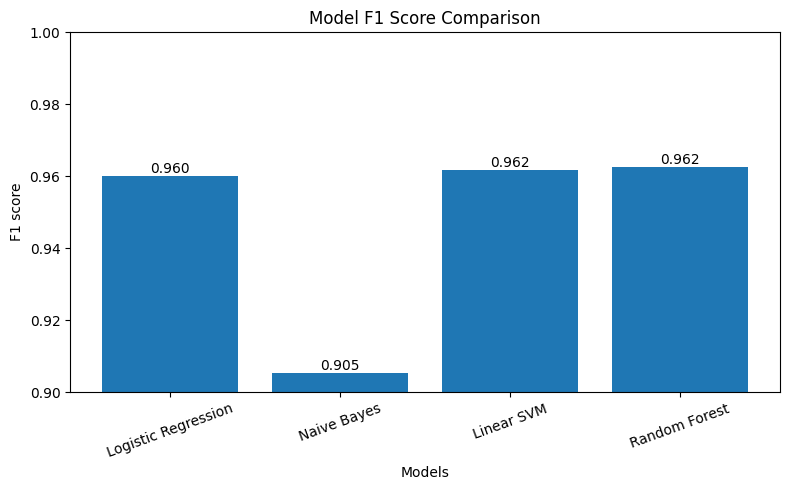

In [16]:
model_names = list(results.keys())
accuracies = list(results.values())
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies)
plt.xlabel("Models")
plt.ylabel("F1 score")
plt.title("Model F1 Score Comparison")
plt.ylim(0.9, 1.0)  
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.3f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.show()
